In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
%matplotlib inline
import tensorflow as tf

In [ ]:
(X_train,y_train) ,(X_test,y_test) = keras.datasets.mnist.load_data()

In [ ]:
X_train.shape

(60000, 28, 28)

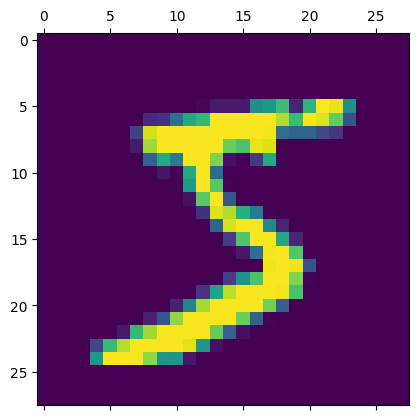

In [ ]:
plt.matshow(X_train[0])

In [ ]:
y_train[0]

np.uint8(5)

In [ ]:
X_train_flattened = X_train.reshape(len(X_train),28*28)
X_train_flattened.shape


(60000, 784)

In [ ]:
X_test_flattened = X_test.reshape(len(X_test),28*28)

In [ ]:
from keras.layers import Dense
model = keras.Sequential([
    Dense(25 ,input_shape = (784,),activation = "relu"),
    Dense(10, activation = "linear")
])
model.compile(optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
              loss = keras.losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics = ["accuracy"]
              )

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.fit(X_train_flattened,y_train,epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.4854 - loss: 6.2856
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8284 - loss: 0.7036
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8805 - loss: 0.5018
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9033 - loss: 0.4029
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9183 - loss: 0.3363


In [ ]:
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9060 - loss: 0.4017


[0.3536466658115387, 0.9147999882698059]

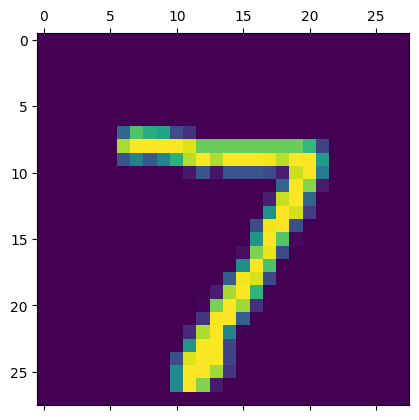

In [ ]:
plt.matshow(X_test[0])

In [ ]:
y_predicted = model.predict(X_test_flattened)
y_softmax = tf.nn.softmax(y_predicted[0])
np.argmax(y_softmax)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


np.int64(7)

In [ ]:
y_test[0]

np.uint8(7)

In [73]:
model_2 = keras.Sequential([
    Dense(35,input_shape = (784,),activation = "relu"),
    Dense(15,activation = "relu"),
    Dense(10,activation = "linear")
])
model_2.compile(loss=keras.losses.SparseCategoricalCrossentropy(from_logits = True),
              optimizer = keras.optimizers.Adam(learning_rate=0.001))
model_2.fit(X_train_flattened,y_train,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - loss: 4.3494
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 1.0582
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.7193
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4877
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.3827


In [74]:
from sklearn.metrics import accuracy_score

model_2_pred = model_2.predict(X_test_flattened);
model_1_pred = model.predict(X_test_flattened);
model_2_pred
test_preds = tf.nn.softmax(model_2_pred)
pred_classes = np.argmax(test_preds,axis = 1)
pred_classes

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


array([7, 2, 1, ..., 4, 5, 6])

In [75]:
model2_error = 1 - accuracy_score(y_test,pred_classes)
model2_error

0.07730000000000004

In [67]:
y_test

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

In [72]:
np.argmax(tf.nn.softmax(model_2.predict(X_test_flattened)),axis = 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([5, 6, 0, ..., 0, 6, 6])